数据分布偏移是一个在机器学习本地部署时常常遇见的问题;一些工作者往往拿到数据后,直接套用模型开始训练,没有考虑到数据分布偏移产生的问题.

一般而言,常见的数据分布偏移有以下几种情况:

1.训练集的输入变量的分布$p(x)$与测试集的输入变量的分布$q(x)$不同,即$q(x) \neq p(x)$,此时我们要对输入变量的分布进行调整,这种情况称为协变量偏移(Covariate Shift).

2.训练集的标签分布$p(y)$与测试集的标签分布$q(y)$不同,即$q(y) \neq p(y)$,此时我们要对标签的分布进行调整,这种情况称为标签偏移(Label Shift).

3.还有一种较为少见的情况,训练集的条件分布$p(x|y)$与测试集的条件分布$q(x|y)$不同,即$q(x|y) \neq p(x|y)$,这种情况称为条件分布偏移(Conditional Distribution Shift)也称概念偏移.

### 协变量偏移修正
对于第一种情况,我们采用如下操作:

考虑一个分类问题,假设训练集和测试集的标签分布相同,即$p(y) = q(y)$,但输入变量的分布不同,即$q(x) \neq p(x)$.假设训练集的损失期望可以写成
$$
E(l(f(\mathbf{x}),y),y)=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) p(y,\mathbf{x}) d\mathbf{x} d y=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) p(y|\mathbf{x})p(\mathbf{x}) d\mathbf{x} d y
$$

同时由于类别的条件分布不变,故我们还可以将上式写为
$$
E(l(f(\mathbf{x}),y))=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) p(y|\mathbf{x})p(\mathbf{x}) d\mathbf{x} d y=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) q(y|\mathbf{x})q(\mathbf{x}) \frac{p(\mathbf{x})}{q(\mathbf{x})}d\mathbf{x} d y
$$

我们令
$$
\beta _i\stackrel{\mathrm{def}}{=}\frac{p(x_i)}{q(x_i)}
$$

同时,我们将上述积分式离散化,同时,使损失期望最小,最终我们有
$$
\text{minimize}_f\frac{1}{n}\sum_{i=1}^n \beta _i l(f(x_i),y_i)
$$

上式在统计学中也被称为经验损失.

现在问题来到如何确定$\beta_i$,一种常见的想法为logistic回归,这是一种Softmax回归的退化情况,专门用于处理二元分类的问题.根据上述说法,我们可以将目标分布的数据集标记为1,源分布的数据集标记为0,然后训练一个logistic回归模型,使得模型的预测值与标签的分布尽量一致.

考虑我们分别从$p(x)$分布和$q(x)$分布中抽取m和n个样本,故我们抽到标签为1(也即源分布)的数据的概率为
$$
P(z=1|\mathbf{x})=\frac{P(z=1,\mathbf{x})}{P(\mathbf{x})}=\frac{P(z=1,\mathbf{x})}{P(z=1,\mathbf{x})+P(z=0,\mathbf{x})}\\
=\frac{P(\mathbf{x}|z=1)P(z=1)}{P(\mathbf{x}|z=1)P(z=1)+P(\mathbf{x}|z=0)P(z=0)}
$$
注意到上式中
$$
P(z=1)=\frac{m}{m+n},P(z=0)=\frac{n}{m+n}\\
P(\mathbf{x}|z=1)=p(\mathbf{x}),P(\mathbf{x}|z=0)=q(\mathbf{x})
$$

带入概率公式,我们可以得到
$$
P(z=1|\mathbf{x})=\frac{mp(\mathbf{x})}{mp(\mathbf{x})+nq(\mathbf{x})}=\frac{m\frac{p(\mathbf{x})}{q(\mathbf{x})}}{m\frac{p(\mathbf{x})}{q(\mathbf{x})}+n}=\frac{m\bold{\beta}}{m\mathbf{\beta}+n}
$$

同时,该概率公式也可通过上文提到的logistic回归模型得到,即
$$
P(z=1|\mathbf{x})=\frac{1}{1+\text{e}^{-h(\mathbf{x})}}
$$

其中$h(x)$为参数函数,由Logistic回归模型学习得到.

对比上述两式,得到
$$
\frac{1}{1+\text{e}^{-h(\mathbf{x})}}=\frac{m\bold{\beta}}{m\mathbf{\beta}+n}=\frac{1}{1+\frac{n}{m}\beta ^{-1}}\\
\Longrightarrow \text{e}^{-h(\mathbf{x})}=(\frac{m}{n}\beta )^{-1}
$$

故我们可以得到
$$
\beta=\frac{n}{m}\text{e}^{h(\mathbf(x))}
$$

最终,我们的损失函数可以写为
$$
\text{minimize}_f\frac{1}{n}\sum_{i=1}^n \frac{n}{m}\text{e}^{h(x_i)} l(f(x_i),y_i)
$$

### 标签变量偏移修正
对于第二种情况,我们有类似的操作:
$$
E(l(f(\mathbf{x}),y))=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) p(\mathbf{x}|y)p(y) d\mathbf{x} d y=\int_{\mathbf{x}} \int_{y} l(f(\mathbf{x}),y) q(\mathbf{x}|y)q(y) \frac{p(y)}{q(y)}d\mathbf{x} d y\\
\Longrightarrow \text{minimize}_f\frac{1}{n}\sum_{i=1}^n \beta _i l(f(x_i),y_i),\quad \beta _i\stackrel{\mathrm{def}}{=}\frac{p(y_i)}{q(y_i)}
$$

一个非常棒的事情是,标签往往是低维,故其对应的分布$q(y)$是极易求得的,问题变为如何求得$p(y)$,即目标分布的标签分布.

考虑一个极强的假设,即训练集与测试集的条件分布严格相等,故我们可以认为模型在这两个数据集上输出的各个分类的概率分布是相同的.换句话说,我们在训练集上得到平均模型输出概率$$\mu(\mathbf{\hat{y}})=\frac{1}{N}\sum_{k=1}^{N} \mathbf{\hat{y}}_k$$
与在测试集得到输出概率应该完全相同,也即
$$
\mathbf{C}p(\mathbf{x})=\mu (\mathbf{\hat{y}})
$$

其中$\mathbf{C}$为训练集的混淆矩阵,同样由于训练集与测试集的条件分布应该严格相等,故两个数据集的混淆矩阵应该也严格相等.特别地,当$\mathbf{C}$可逆时,我们有

$$
p(\mathbf{x})=\mathbf{C}^{-1}\mu (\mathbf{\hat{y}})
$$

故我们有
$$
\beta=\frac{\mathbf{C}^{-1}\frac{1}{N}\sum_{k=1}^{N} \mathbf{\hat{y}}_k}{q(\mathbf{y})}
$$

最终,我们的损失函数可以写为
$$
\text{minimize}_f\frac{1}{n}\frac{c_{ik}\frac{1}{N}\sum_{k=1}^{N} \hat{y}_{ik}}{q(y_i)} l(f(x_i),y_i)
$$

### 条件分布偏移修正

该种情况发生的较少,一般直接采用训练集的条件分布$p(x|y)$来训练模型,而测试集的条件分布$q(x|y)$则不用考虑.

In [1]:

import numpy as np
import torch
import torch.nn as nn
from d2l import torch as d2l
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt



In [ ]:
def genertated_data(w, b, num_examples,is_train=True):  #@save
    """生成y = Xw + b + 噪声。"""
    if is_train==True:
        X= torch.normal(0, 0.1, (num_examples, len(w)))
        y = torch.matmul(X, w) + b
        y += torch.normal(0, 0.01, y.shape)
        y=(y>0).type(torch.float32)
        label=torch.ones(num_examples)
    else:
        X= torch.normal(3, 2, (num_examples, len(w)))
        y = torch.matmul(X, w) + b
        y += torch.normal(0, 0.01, y.shape)
        y=(y>0).type(torch.float32)
        label=torch.zeros(num_examples)
    return X, y.reshape((-1, 1)),label.reshape((-1, 1))

real_w =torch.tensor([2, -3.4, 3.6])
real_b =1.2

train_features, train_values,train_labels = genertated_data(real_w, real_b, 1000,is_train=True)
test_features, test_values,test_labels = genertated_data(real_w, real_b, 500,is_train=False)
train_iter=DataLoader(TensorDataset(train_features, train_values), batch_size=32, shuffle=True)
test_iter=DataLoader(TensorDataset(test_features, test_values), batch_size=32)

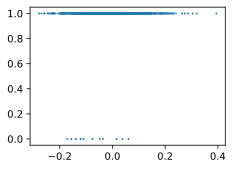

In [3]:

d2l.set_figsize()
# Generate synthetic data

d2l.plt.scatter(train_features[:, (0)].detach().numpy(), train_values.detach().numpy(), 1);
d2l.plt.show()

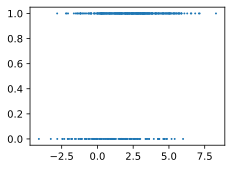

In [4]:

d2l.set_figsize()
# Generate synthetic data

d2l.plt.scatter(test_features[:, (0)].detach().numpy(), test_values.detach().numpy(), 1);
d2l.plt.show()

In [5]:

domain_train_X = train_features
domain_train_y = train_labels
domain_test_X = test_features
domain_test_y = test_labels

# 合并
domain_X = torch.cat([domain_train_X, domain_test_X], dim=0)
domain_y = torch.cat([domain_train_y, domain_test_y], dim=0)
print(domain_X, domain_y)

domain_dataset = TensorDataset(domain_X, domain_y)
domain_loader = DataLoader(domain_dataset, batch_size=32, shuffle=True)


tensor([[ 2.6388e-01,  1.1376e-01, -2.4425e-02],
        [-8.6175e-02,  1.1081e-01, -4.5829e-02],
        [-3.9503e-02,  5.8759e-02, -6.4165e-03],
        ...,
        [ 1.7850e+00,  2.2020e+00,  7.4882e+00],
        [ 8.7971e-01,  1.9225e+00,  3.8828e+00],
        [ 3.3647e+00,  7.3749e-02,  3.7641e+00]]) tensor([[1.],
        [1.],
        [1.],
        ...,
        [0.],
        [0.],
        [0.]])


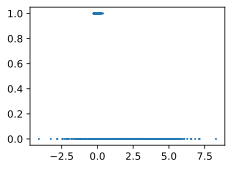

In [6]:
d2l.set_figsize()
# Generate synthetic data

d2l.plt.scatter(domain_X[:, 0].detach().numpy(), domain_y.detach().numpy(), 1);

d2l.plt.show()

In [7]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
 
loss = nn.BCEWithLogitsLoss()#不能使用传统的交叉损失函数,因为我这里的标签是0和1，而不是独热编码,同样也不能使用Utils中的多分类训练函数,因为这里是二分类问题,标签只有一维,train_classify处理的多分类问题中,标签是多维度的.

model_domain = Classifier()
optimizer = optim.SGD(model_domain.parameters(), lr=0.01)
num_epochs = 100



In [9]:
from utils.tool import train_domain_classifier
train_domain_classifier(model_domain, domain_loader, loss, optimizer, num_epochs)

Epoch 0: loss=33.3137, acc=0.3247
Epoch 1: loss=31.0632, acc=0.3340
Epoch 2: loss=28.9412, acc=0.9673
Epoch 3: loss=26.7965, acc=0.9580
Epoch 4: loss=24.5839, acc=0.9520
Epoch 5: loss=22.3634, acc=0.9553
Epoch 6: loss=20.2194, acc=0.9573
Epoch 7: loss=18.2449, acc=0.9613
Epoch 8: loss=16.4817, acc=0.9620
Epoch 9: loss=14.9305, acc=0.9620
Epoch 10: loss=13.5764, acc=0.9627
Epoch 11: loss=12.4024, acc=0.9647
Epoch 12: loss=11.3854, acc=0.9653
Epoch 13: loss=10.4965, acc=0.9660
Epoch 14: loss=9.7278, acc=0.9673
Epoch 15: loss=9.0557, acc=0.9680
Epoch 16: loss=8.4621, acc=0.9693
Epoch 17: loss=7.9495, acc=0.9693
Epoch 18: loss=7.5047, acc=0.9700
Epoch 19: loss=7.0806, acc=0.9713
Epoch 20: loss=6.7152, acc=0.9727
Epoch 21: loss=6.4093, acc=0.9733
Epoch 22: loss=6.0999, acc=0.9733
Epoch 23: loss=5.8361, acc=0.9733
Epoch 24: loss=5.6005, acc=0.9740
Epoch 25: loss=5.3800, acc=0.9747
Epoch 26: loss=5.1825, acc=0.9753
Epoch 27: loss=5.0136, acc=0.9753
Epoch 28: loss=4.8388, acc=0.9767
Epoch 29: 

In [10]:
prob=torch.exp(model_domain(domain_X))


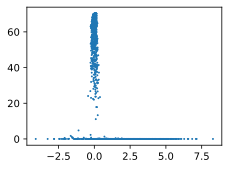

In [11]:

d2l.set_figsize()
# Generate synthetic data

d2l.plt.scatter(domain_X[:, 0].detach().numpy(), prob.detach().numpy(), 1);

d2l.plt.show()

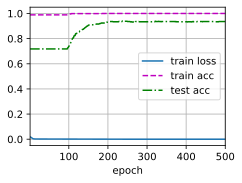

In [19]:
from utils.tool import train_classify
net=Classifier()
trainer= torch.optim.Adam(net.parameters(), lr=0.001)
train_classify(net,train_iter,test_iter,loss,trainer,num_epochs=500,is_binary=True)


In [13]:
def loss_optimal(y_hat,y,train_features,test_features,model):
    loss_optimal=(len(test_features)/len(train_features))*nn.MSELoss()(y_hat, y)*torch.min(torch.exp(model(train_features)).squeeze(),torch.tensor(10.0))
    return loss_optimal

In [14]:
def accuracy(y_pred, y):
    """accuracy of predicted labels and true labels"""
    if len(y_pred.shape) > 1 and y_pred.shape[1] > 1:
        y_pred = y_pred.argmax(axis=1)
    cmp = y_pred.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter):
    """Evaluate accuracy of a model on a dataset."""
    if isinstance(net, torch.nn.Module):
        net.eval()  # Set the model to evaluation mode
    metric = d2l.Accumulator(2)  # No. of correct predictions, no. of predictions
    with torch.no_grad():
        for X, y in data_iter:
                   pred = (torch.sigmoid(net(X)) > 0.5).long()
                   metric.add( (pred == y).sum().item(), y.numel())
    return metric[0] / metric[1]

def train_epoch_ch3(net, train_iter, updater,test_features,model):
    """The training function for one epoch defined in Chapter 3."""
    # Set the model to training mode
    if isinstance(net, torch.nn.Module):
        net.train()
    # Sum of training loss, sum of training accuracy, no. of examples
    metric = d2l.Accumulator(3)
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss_optimal(y_hat, y,train_features,test_features,model)
        if isinstance(updater, torch.optim.Optimizer):
            # Using PyTorch built-in optimizer and loss criterion
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # Using custom updater in Chapter 3 (minibatch stochastic gradient descent)
            l.sum().backward()
            updater(X.shape[0])
        # Update training loss and accuracy
        pred = (torch.sigmoid(y_hat) > 0.5).long()
        metric.add(float(l.sum()), (pred == y).sum().item(), y.numel())
    # Return training loss and training accuracy
    return metric[0] / metric[2], metric[1] / metric[2]

def train_classify(test_features,model,net, train_iter, test_iter, updater, num_epochs,is_binary=None,):
    """Train a model (defined in Chapter 3)."""
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, updater,test_features,model)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, f'train_loss={train_loss}'
    assert train_acc <= 1 and train_acc > 0.7, f'train_acc={train_acc}'
    assert test_acc <= 1 and test_acc > 0.5, f'test_acc={test_acc}'


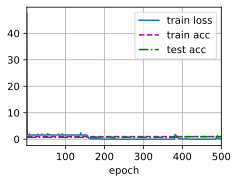

In [15]:
final_net=Classifier()
trainer= torch.optim.Adam(final_net.parameters(), lr=0.01)

train_classify(test_features,model_domain,final_net,train_iter,test_iter,trainer,500,is_binary=True)


In [27]:
print("原始模型在测试集上的准确率：",evaluate_accuracy(net,test_iter))
print("修正后模型在测试集上的准确率：",evaluate_accuracy(final_net,test_iter))

原始模型在测试集上的准确率： 0.936
修正后模型在测试集上的准确率： 0.942


其实这个部分的代码有点问题,不管是何种分布偏移,一般多出现在分类问题中,所以下面拿回归问题来举例子不太合适,其实原理差不多,所以我就不改了(11.22.15:20)

算了,因为我不想写标签条件偏移修正的代码了,所以我还是把之前的回归问题修成分类问题的形式,这样比较好理解(11.22.18:23)

summary:真的没想到会花将近3h来重写,主要是典中典的updater又混用了,导致新的nn的参数不更新,所以训练一直失败,还就是binary_classify的准确率需要sigmoid函数来激活,不然输出全是0,也无法进行训练,还好现在写完了.
